# Programa de Capacitação de Processamento Digital de Sinais

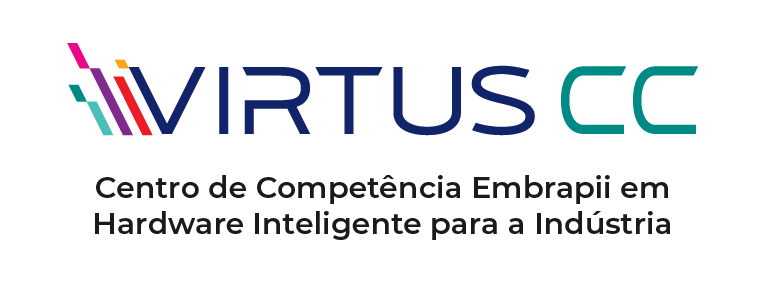


### Desenvolvido por:
-   Elmer Pimentel Farias



### Capítulos 4, 5 e 6 — Filtros Digitais  
**Baseado no livro “Processamento Digital de Sinais” — Paulo S. R. Diniz**

---

## Capítulo 4 — Filtros Digitais
O Capítulo 4 apresenta os fundamentos dos **filtros digitais**, dispositivos utilizados para modificar o espectro de um sinal de acordo com critérios de frequência.

São discutidos:
- As classificações: **passa-baixas**, **passa-altas**, **passa-faixa** e **rejeita-faixa**;  
- As diferenças entre filtros de **resposta ao impulso finita (FIR)** e **resposta ao impulso infinita (IIR)**;  
- A representação em **domínio Z**, o **diagrama de polos e zeros** e a **resposta em frequência**.

---

## Capítulo 5 — Filtros FIR
Os filtros **FIR (Finite Impulse Response)** possuem resposta ao impulso de duração finita, garantindo **estabilidade incondicional** e **fase linear**.

O capítulo enfatiza o **método de projeto por janelamento**, em especial o uso da **janela de Hamming**, que permite controlar a largura de banda e a atenuação do filtro.  
A análise da **resposta em frequência** e da **fase** é essencial para avaliar o desempenho e a seletividade do filtro.

---

## Capítulo 6 — Filtros IIR
Os filtros **IIR (Infinite Impulse Response)** são caracterizados pela **realimentação**, o que proporciona maior eficiência e seletividade espectral.  
Contudo, exigem cuidado com a **estabilidade** e a **linearidade de fase**.

São estudados os principais tipos:
- **Butterworth:** resposta suave e monotônica;  
- **Chebyshev:** maior seletividade à custa de ondulações na banda passante;  
- **Elíptico:** alta seletividade, porém com ondulações em ambas as bandas.

---

## Objetivos da Capacitação

1. **Projetar e aplicar** um **filtro FIR passa-baixas** utilizando a **janela de Hamming** em sinais ruidosos, comparando os sinais de entrada e saída.  
2. **Projetar e aplicar** um **filtro IIR Butterworth passa-altas** em sinais ruidosos, comparando os sinais de entrada e saída.  
3. **Analisar** a **resposta em frequência e fase** dos filtros projetados, avaliando suas características e desempenho.

---

*Capítulos 4, 5 e 6 — Livro “Processamento Digital de Sinais”, Paulo S. R. Diniz.*


## Bibliotecas Importadas e Necessárias 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.signal as signal
from numba import njit, jit , vectorize , prange
#import cupy as cp
#import cupyx
from scipy.signal import freqz
from scipy import signal

# Aproximações para Filtros FIR
### Características Ideais na Frequência e Respostas ao Impulso Correspondentes para Filtros Passa-Baixas, Passa-Altas, Passa-Faixa e Rejeita-Faixa
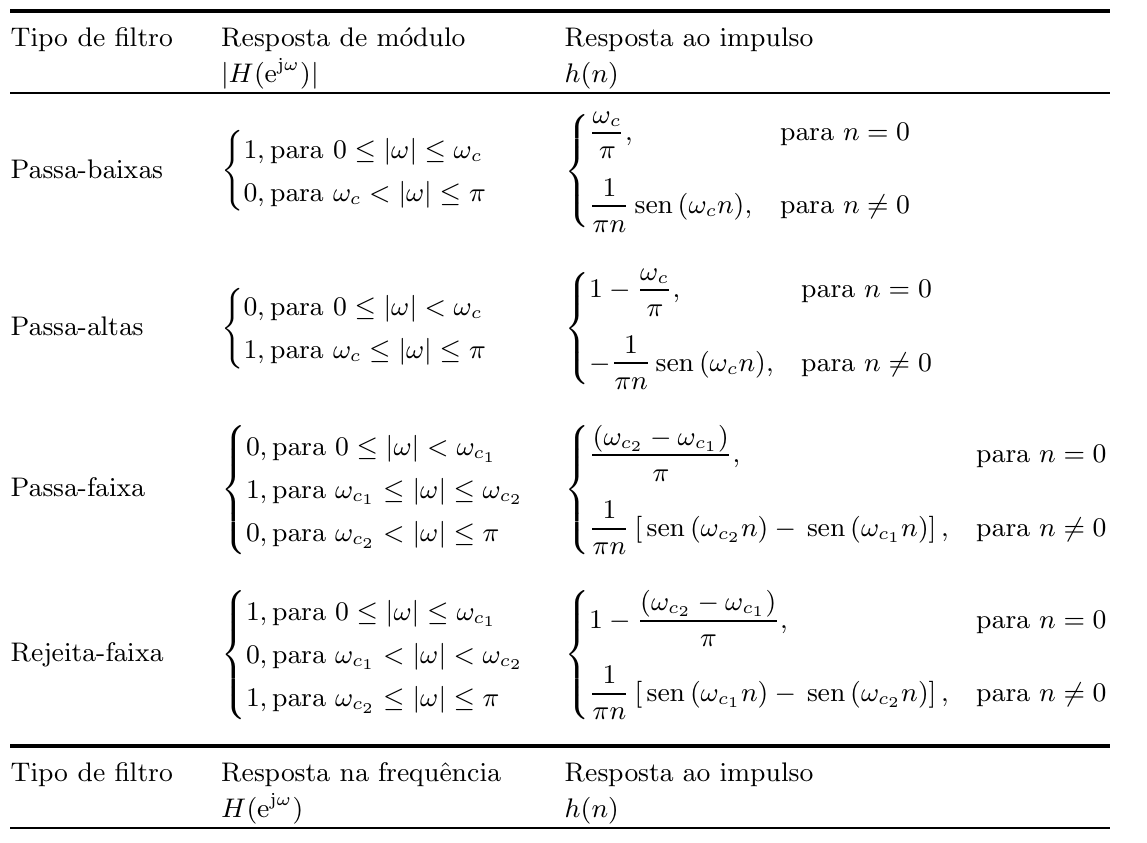

# Filtro Passa Baixa Ideal 



In [3]:
@njit(parallel=True)
def low_pass(N, fc, fs):
    """
    Calcula os coeficientes h[n] de um filtro FIR passa-baixa ideal
    usando um laço 'for' explícito.

    Argumentos:
    N (int): Ordem do filtro (número de coeficientes).
    fc (float): Frequência de corte (em Hertz).
    fs (float): Frequência de amostragem (em Hertz).

    Retorna:
    numpy.ndarray: Vetor de coeficientes h[n] do filtro.
    """
    
    # 1. CONVERSÃO: Calcula a frequência de corte digital (rad/amostra)
    #    a partir das frequências em Hertz.
    wc = 2 * np.pi * (fc / fs)
    
    # 2. Aloca um vetor 'h' vazio (cheio de zeros)
    h = np.zeros(N)
    
    # 3. Calcula o ponto médio (atraso)
    M = (N - 1) / 2
    
    # 4. Itera por cada índice 'n' do filtro
    for n in prange(N):
        # 5. Calcula o eixo 'n' centrado
        n_desloc = n - M
        
        # 6. Trata o caso especial (n = M)
        # Se n_shifted == 0, o limite é wc/pi
        if n_desloc == 0:
            h[n] = wc / np.pi
        else:
            # 7. Calcula todos os outros valores
            # Fórmula: sin(wc * n_desloc) / (pi * n_desloc)
            h[n] = np.sin(wc * n_desloc) / (np.pi * n_desloc)

    return h

## Plotando os Coeficientes,  Magnitude e Fase do Filtro Passa-Baixa 

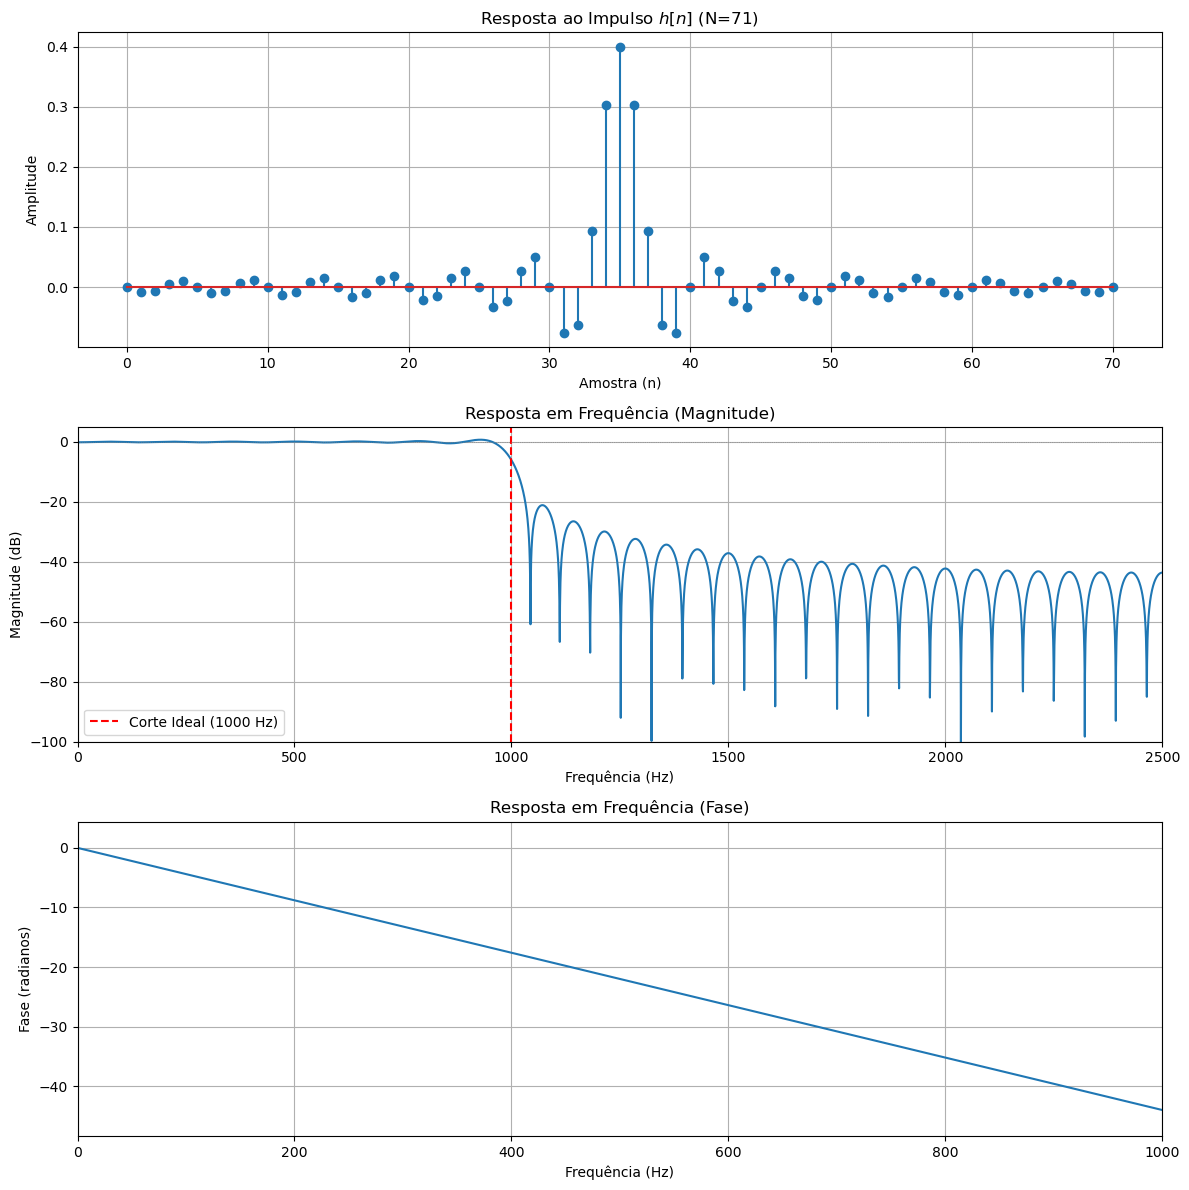

In [4]:
# Parâmetros do Filtro
N = 71     # Ordem do filtro (número de coeficientes)
                
fs = 5000        # Frequência de amostragem (Hz)
fc = 1000        # Frequência de corte (Hz) 

#Coeficientes do filtro

h = low_pass(N, fc, fs)

# CALCULAR A RESPOSTA EM FREQUÊNCIA (W e H)
# w: vetor de frequências em rad/amostra
# H: vetor da resposta em frequência (complexa)
# worN= aumenta a resolução do gráfico
w, H = freqz(h, worN=fs)

# ---------------------------------------------------
f_hz = (w / (2 * np.pi)) * fs
db_magnitude = 20 * np.log10(np.abs(H) + 1e-9)

# Cálculo da fase
phase_rad = np.angle(H)

# np.unwrap() remove os saltos de 2*pi para vermos a linha reta
phase_unwrapped = np.unwrap(phase_rad)

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

# Plot 1: Resposta ao Impulso (em axs[0]) 
axs[0].stem(np.arange(N), h)
axs[0].set_title(f'Resposta ao Impulso $h[n]$ (N={N})')
axs[0].set_xlabel('Amostra (n)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

# Plot 2: Resposta em Frequência (Magnitude) (em axs[1]) 
axs[1].plot(f_hz, db_magnitude)
axs[1].axvline(fc, color='red', linestyle='--', label=f'Corte Ideal ({fc} Hz)')
axs[1].axhline(0, color='gray', linestyle=':', linewidth=0.5)
axs[1].set_title('Resposta em Frequência (Magnitude)')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Magnitude (dB)')
axs[1].set_ylim(-100, 5)
axs[1].set_xlim(0, fs / 2)
axs[1].legend()
axs[1].grid(True)

# Plot 3: Resposta em Frequência (Fase) (em axs[2]) 
axs[2].plot(f_hz, phase_unwrapped)
axs[2].set_title('Resposta em Frequência (Fase)')
axs[2].set_xlabel('Frequência (Hz)')
axs[2].set_ylabel('Fase (radianos)')
# 1. Limitar o eixo X para a banda passante (0 até fc)
axs[2].set_xlim(0, fc)

# Encontra o índice do array f_hz mais próximo de fc
zoom_index_limit = np.max(np.where(f_hz <= fc))

# A fase (desembrulhada) começa em 0 e desce
min_phase = phase_unwrapped[zoom_index_limit]
max_phase = 0 # A fase em 0 Hz é 0

# 3. Adiciona uma pequena margem (10%) no eixo Y
margin = np.abs(min_phase) * 0.1
axs[2].set_ylim(min_phase - margin, max_phase + margin)

axs[2].grid(True)


plt.tight_layout() # Ajusta os plots para não sobrepor
plt.show()

#  Aproximação de Filtros FIR com Funções-Janela

Afim de evitar as respostas ao impulso com duração infinita dados os filtros ideais, logo levando a filtros não-realizaveis, devemos fazer uma aproximação dos filtro FIR via funções-janela multiplicando a resposta ao impulso $h(n)$ por uma função-janela $w(n)$. 

A janela $w(n)$ tem que ser projetada de forma a introduzir um mínimo de desvio em relação à resposta na frequência ideal. Os coeficientes da resposta ao impulso resultante $h'(n)$ se tornam

$h'(n) = h(n)w(n).$

No domínio da frequência, tal multiplicação corresponde à convolução periódica entre as respostas na frequência do filtro ideal, $H(e^{j\omega})$, e da função-janela. $W(e^{j\omega})$, isto é:

$H'(e^{j\omega}) = \frac{1}{2\pi} \int_{-\pi}^{\pi} H(e^{j\omega'})W(e^{j(\omega-\omega')})d\omega'.$

Podemos inferir, então, que uma boa janela é uma sequência de comprimento finito cuja resposta na frequência, quando convolvida com uma resposta na frequência ideal, produz a menor distorção possível.

Isso significa que devemos encontrar uma janela de comprimento finito cuja resposta na frequência tenha a maior parte de sua energia concentrada em torno de $\omega = 0$.

## Janelas de Hamming

A janela de Hamming generalizada é definida como

$w_{H}(n) = \begin{cases} \alpha + (1-\alpha) \cos \frac{2\pi n}{M}, & \text{para } |n| \le M/2 \\ 0, & \text{para } |n| > M/2, \end{cases}$
com $0 \le \alpha \le 1$.

 Essa janela generalizada é chamada de janela de Hamming quando $\alpha = 0,54$, e quando $\alpha = 0,5$ é conhecida como janela de Hann ou Hanning. A resposta na frequência para a janela de Hamming generalizada pode ser expressa com base na resposta na frequência da janela retangular. Primeiramente, escrevemos a equação como

$w_{H}(n) = w_{r}(n) \left[ \alpha + (1-\alpha) \cos \frac{2\pi n}{M} \right].$

In [5]:
#Janela de Hamming
@njit
def hamming_window(N):
    """
    Gera uma janela de Hamming de tamanho N.

    Argumentos:
    N (int): Tamanho da janela.

    Retorna:
    numpy.ndarray: Vetor contendo a janela de Hamming.
    """
    M = N - 1
    n = np.arange(N)
    alpha = 0.54
    window_h = alpha - (1 - alpha) * np.cos((2 * np.pi * n) / M)
    return window_h


#### $h'(n) = h(n)w(n).$

In [6]:
@njit
def LP_hamming(N, fc, fs):
  
    # 1. Calcula os coeficientes do filtro passa-baixa ideal
    h_ideal = low_pass(N, fc, fs)
    
    # 2. Gera a janela de Hamming
    window_h = hamming_window(N)
    
    # 3. Aplica a janela aos coeficientes ideais
    h_windowed = h_ideal * window_h
    
    h_windowed /= np.sum(h_windowed)  # Normaliza para ganho DC = 1
    
    return h_windowed, window_h

# Plote do Filtro de Hamming Passa-Baixa

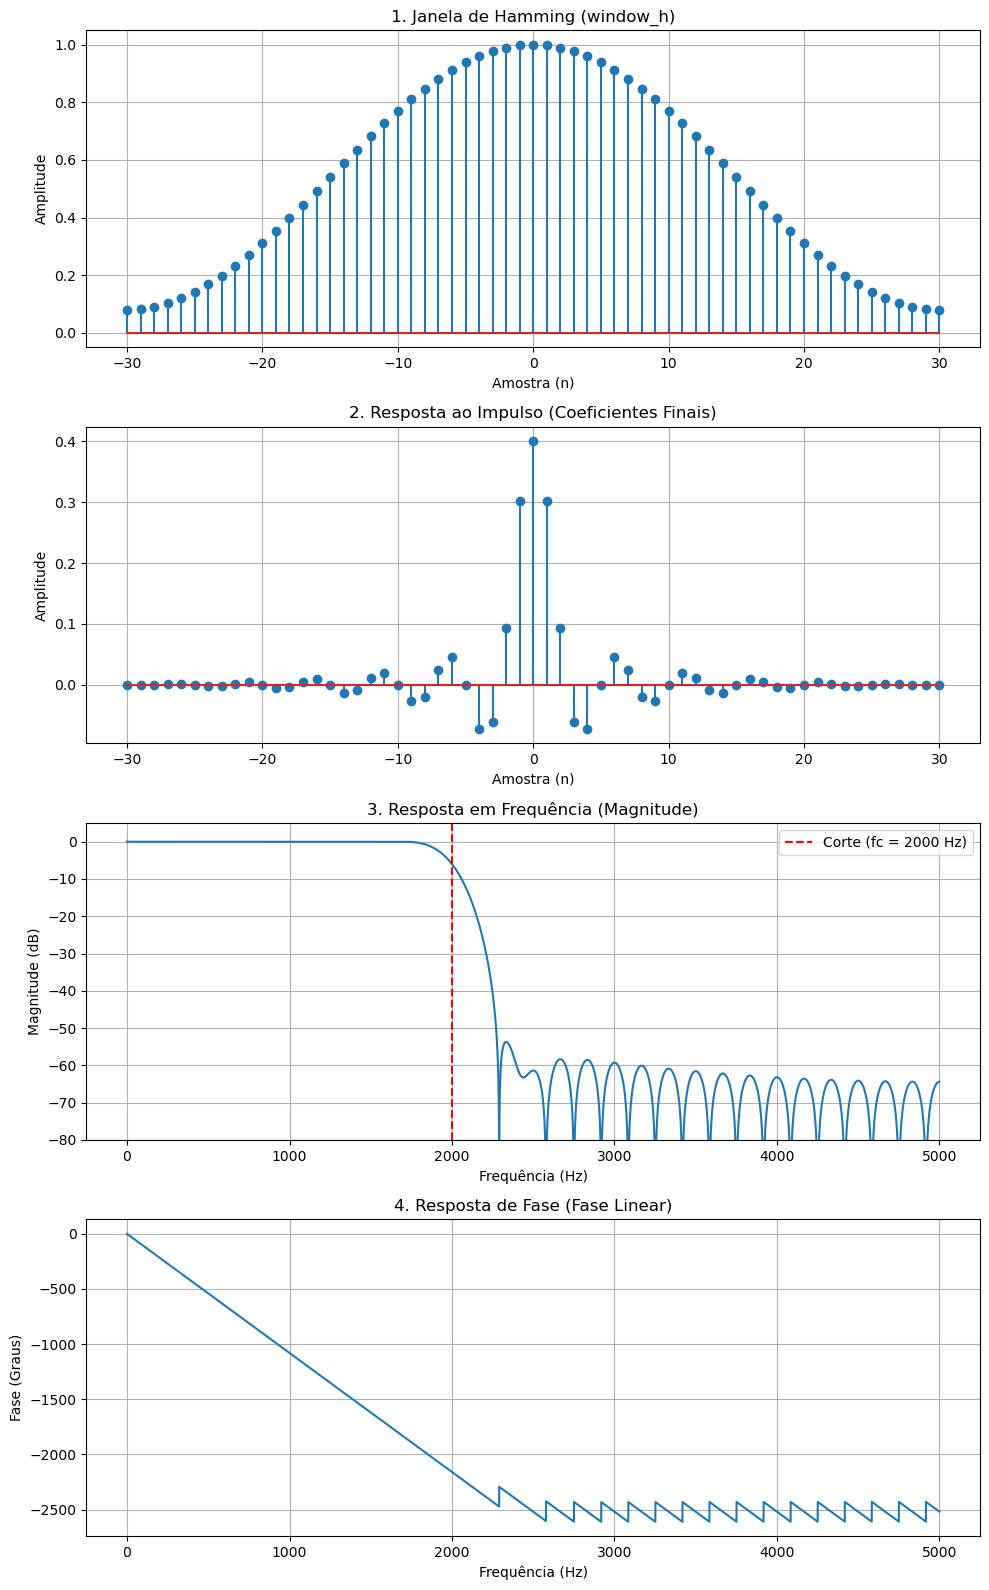

In [7]:
N = 61                # Ordem do filtro (tamanho)
fs = 10000            # Frequência de amostragem (12 kHz)
fc = 2000             # Frequência de corte (5 kHz)

# Cria o eixo de tempo 't' centrado em zero
t = np.arange(N) - (N - 1) / 2
hamming_windowed, window_h = LP_hamming(N, fc, fs)

w, H = freqz(hamming_windowed, 1, worN=8192, fs=fs)

# --- 5. Geração dos Gráficos em 'axs' ---
fig, axs = plt.subplots(4, 1, figsize=(10, 16)) 

# Gráfico 1: Janela de Hamming 
axs[0].stem(t, window_h, 'o-')
axs[0].set_title("1. Janela de Hamming (window_h)")
axs[0].set_xlabel("Amostra (n)")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)
# 

# Gráfico 2: Resposta ao Impulso (Coeficientes)
axs[1].stem(t, hamming_windowed, 'o-')
axs[1].set_title("2. Resposta ao Impulso (Coeficientes Finais)")
axs[1].set_xlabel("Amostra (n)")
axs[1].set_ylabel("Amplitude")
axs[1].grid(True)

# Gráfico 3: Módulo em dB
magnitude_db = 20 * np.log10(np.abs(H))
axs[2].plot(w, magnitude_db)
axs[2].set_title("3. Resposta em Frequência (Magnitude)")
axs[2].set_xlabel("Frequência (Hz)")
axs[2].set_ylabel("Magnitude (dB)")
axs[2].axvline(fc, color='r', linestyle='--', label=f'Corte (fc = {fc} Hz)')
axs[2].set_ylim(-80, 5) 
axs[2].grid(True)
axs[2].legend()

# Gráfico 4: Fase 
phase = np.unwrap(np.angle(H))
phase_degrees = np.rad2deg(phase)

axs[3].plot(w, phase_degrees)
axs[3].set_title("4. Resposta de Fase (Fase Linear)")
axs[3].set_xlabel("Frequência (Hz)")
axs[3].set_ylabel("Fase (Graus)")
axs[3].grid(True)

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.show()

        

## Aplicação do Filtro via biblioteca SoundDevice

Gravar um áudio com usando o microfone padrão do usuário e somar a um ruído randomico, com o intuito de usar o Filtro de Hamming Passa-Baixa. 

Analisar os espectros de frequência do sinais de entrada e saída.

Gravação de 5 segundos iniciará em...
3...
2...
1... FALE e ASSOBIE!
Gravação completa.
Projetando e aplicando filtro LP de 1000 Hz...
Filtro aplicado.
Calculando e plotando espectros...

Reproduzindo o áudio ORIGINAL ...
Reproduzindo o áudio FILTRADO (som 'abafado')...

Concluído.


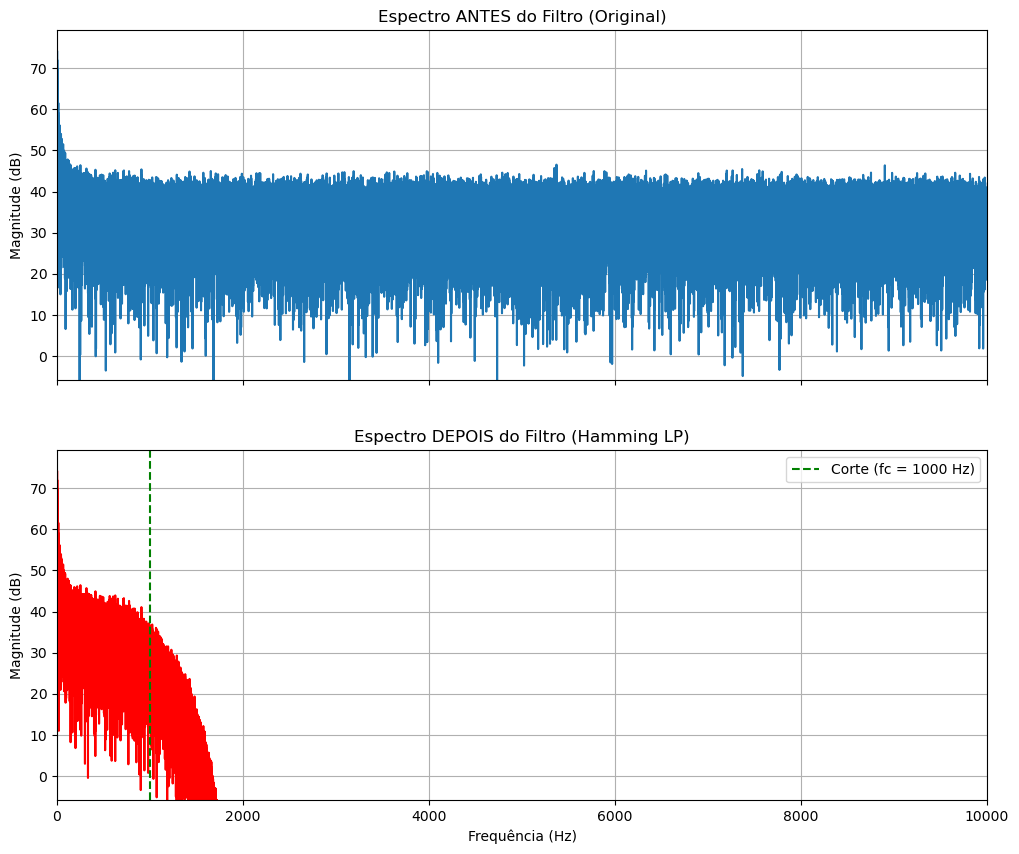

In [8]:
import sounddevice as sd
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import scipy.signal as sig


fs = 44100
duracao = 8 # Vamos gravar por 5 segundos
N_filtro = 101 # Ordem do filtro
fc_filtro = 1000 # Frequência de corte (2000 Hz)

print("Gravação de 5 segundos iniciará em...")
time.sleep(1); print("3..."); time.sleep(1); print("2..."); time.sleep(1); print("1... FALE e ASSOBIE!")

# 1. Grava o áudio
meu_audio = sd.rec(int(duracao * fs), samplerate=fs, channels=1, dtype='float32')
sd.wait() # Espera a gravação terminar
print("Gravação completa.")
time.sleep(0.5)


ruido = np.random.normal(0, 0.1, meu_audio.shape)
meu_audio += ruido

# --- 3. PROJETA E APLICA O FILTRO ---
print(f"Projetando e aplicando filtro LP de {fc_filtro} Hz...")

# 3a. Projeta o filtro
# A função está retornando uma tupla, ex: (array([0.1, 0.2, ...]),)
h_filtro_output = LP_hamming(N=N_filtro, fc=fc_filtro, fs=fs)

# 3b. Aplica o filtro
audio_1d = meu_audio.flatten() # Este é float32

# -----------------

# 1. Checa se é uma tupla e extrai o primeiro elemento (o array)
if isinstance(h_filtro_output, tuple):
    h_filtro = h_filtro_output[0] 
else:
    h_filtro = h_filtro_output # Caso já esteja correto

# 2. Converte o array para float32 para bater com o áudio
h_filtro_32 = h_filtro.astype(np.float32)
# -----------------

# filtro de 32 bits na função
audio_filtrado = sig.lfilter(h_filtro_32, 1.0, audio_1d)

print("Filtro aplicado.")

# --- 4. PLOTS DE COMPARAÇÃO (ANTES E DEPOIS) ---
print("Calculando e plotando espectros...")

# Cria os eixos para 2 gráficos (2 linhas, 1 coluna)
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True, sharey=True)

# 4a. FFT do Áudio ORIGINAL
N = len(audio_1d)
yf_orig = fft(audio_1d) 
xf_orig = fftfreq(N, 1 / fs)

N_half = N // 2
xf_pos = xf_orig[:N_half]
yf_db_orig = 20 * np.log10(np.abs(yf_orig[:N_half]) + 1e-12)

# Plot do Original
axs[0].plot(xf_pos, yf_db_orig)
axs[0].set_title("Espectro ANTES do Filtro (Original)")
axs[0].set_ylabel("Magnitude (dB)")
axs[0].grid(True)

# 4b. FFT do Áudio FILTRADO
yf_filt = fft(audio_filtrado) 
# xf é o mesmo
yf_db_filt = 20 * np.log10(np.abs(yf_filt[:N_half]) + 1e-12)

# Plot do Filtrado
axs[1].plot(xf_pos, yf_db_filt, color='r')
axs[1].axvline(fc_filtro, color='g', linestyle='--', label=f'Corte (fc = {fc_filtro} Hz)')
axs[1].set_title("Espectro DEPOIS do Filtro (Hamming LP)")
axs[1].set_xlabel("Frequência (Hz)")
axs[1].set_ylabel("Magnitude (dB)")
axs[1].grid(True)
axs[1].legend()

# Ajustes finais dos eixos
max_db = np.max(yf_db_orig)
plt.xlim(0, 10000) # Foco em 0-10kHz
plt.ylim(max_db - 80, max_db + 5) # Janela de 80dB


# --- 5. TOCAR OS ÁUDIOS ---
print("\nReproduzindo o áudio ORIGINAL ...")
sd.play(meu_audio, fs)
sd.wait() # Espera a reprodução terminar
time.sleep(0.5)

print("Reproduzindo o áudio FILTRADO (som 'abafado')...")
sd.play(audio_filtrado, fs)
sd.wait() # Espera a reprodução terminar

print("\nConcluído.")

### Repetir o Áudio Original e o Áudio Filtrado

In [9]:
sd.play(meu_audio, fs)
sd.wait() 
time.sleep(0.5)

sd.play(audio_filtrado, fs)

In [10]:
import numpy as np
from numba import njit, prange

@njit(parallel=True)
def high_pass(N, fc, fs):
    """
    Calcula os coeficientes h[n] de um filtro FIR passa-alta ideal
    baseado na fórmula fornecida na imagem.

    Argumentos:
    N (int): Ordem do filtro (número de coeficientes).
    fc (float): Frequência de corte (em Hertz).
    fs (float): Frequência de amostragem (em Hertz).

    Retorna:
    numpy.ndarray: Vetor de coeficientes h[n] do filtro.
    """
    
    # 1. CONVERSÃO: Calcula a frequência de corte digital (rad/amostra)
    wc = 2 * np.pi * (fc / fs)
    
    # 2. Aloca o vetor 'h'
    h = np.zeros(N)
    
    # 3. Calcula o ponto médio (atraso de grupo para fase linear)
    M = (N - 1) / 2
    
    # 4. Itera por cada índice 'n' do filtro
    for n in prange(N):
        # 5. Calcula o eixo 'n' centrado (equivalente ao 'n' da fórmula matemática)
        n_desloc = n - M
        
        # 6. Trata o caso especial (n = 0 na fórmula matemática)
        if n_desloc == 0:
            # Fórmula da imagem para n=0: 1 - (wc / pi)
            h[n] = 1 - (wc / np.pi)
        else:
            # 7. Calcula todos os outros valores
            # Fórmula da imagem para n!=0: - (1 / (pi*n)) * sin(wc*n)
            h[n] = -np.sin(wc * n_desloc) / (np.pi * n_desloc)

    return h

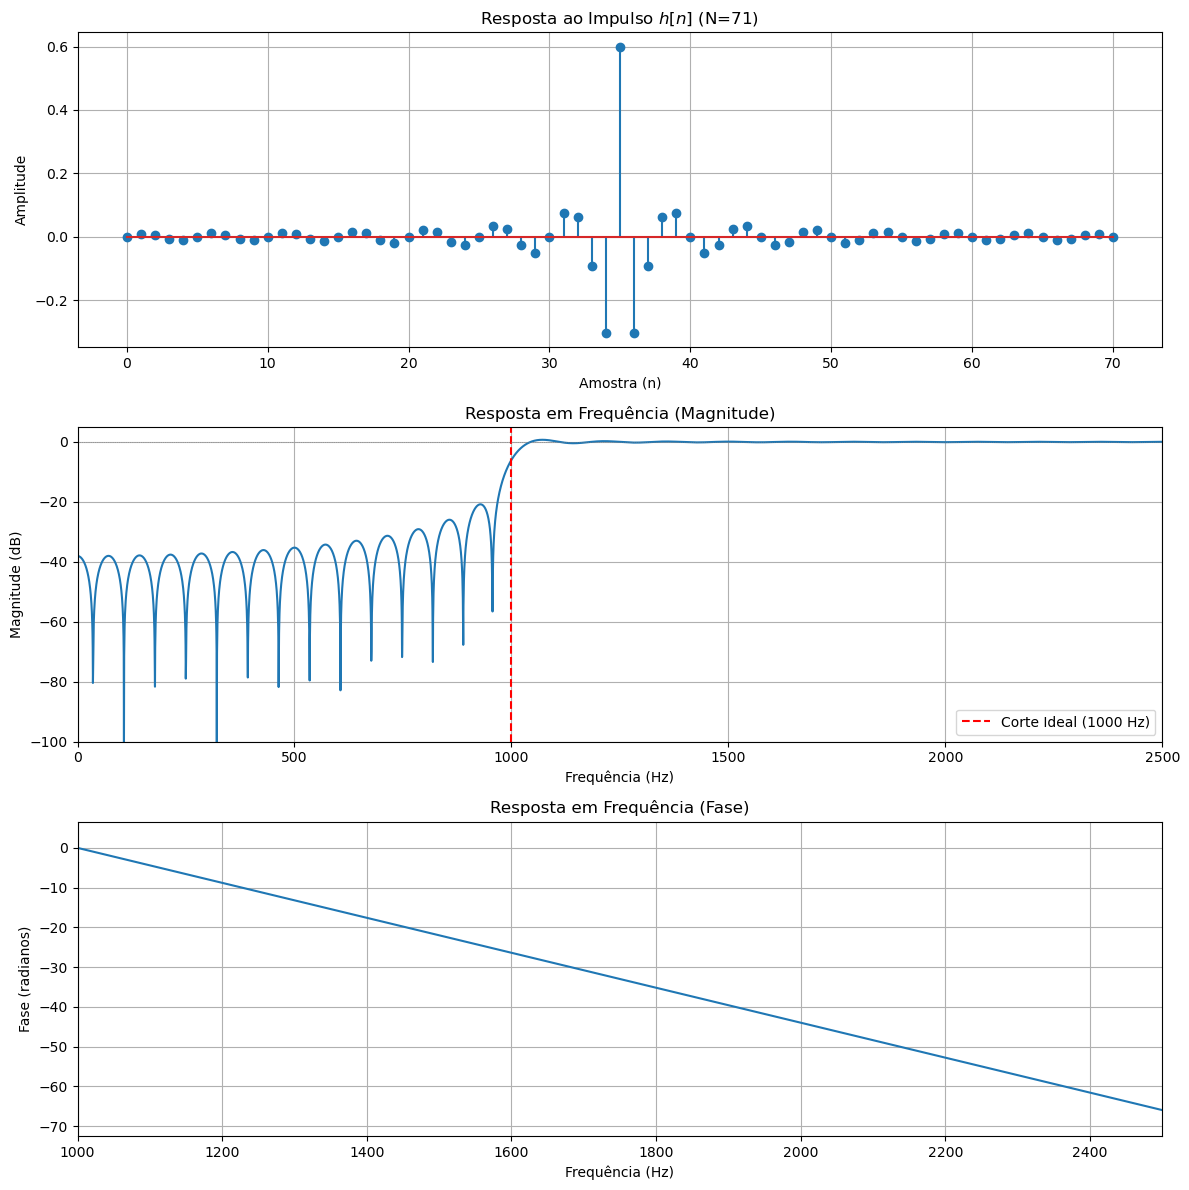

In [11]:
# Parâmetros do Filtro
N = 71     # Ordem do filtro (número de coeficientes)
                
fs = 5000        # Frequência de amostragem (Hz)
fc = 1000        # Frequência de corte (Hz) 

#Coeficientes do filtro

h = high_pass(N, fc, fs)

# CALCULAR A RESPOSTA EM FREQUÊNCIA (W e H)
# w: vetor de frequências em rad/amostra
# H: vetor da resposta em frequência (complexa)
# worN= aumenta a resolução do gráfico
w, H = freqz(h, worN=fs)

# ---------------------------------------------------
f_hz = (w / (2 * np.pi)) * fs
db_magnitude = 20 * np.log10(np.abs(H) + 1e-9)

# Cálculo da fase
phase_rad = np.angle(H)

# np.unwrap() remove os saltos de 2*pi para vermos a linha reta
phase_unwrapped = np.unwrap(phase_rad)

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

# Plot 1: Resposta ao Impulso (em axs[0]) 
axs[0].stem(np.arange(N), h)
axs[0].set_title(f'Resposta ao Impulso $h[n]$ (N={N})')
axs[0].set_xlabel('Amostra (n)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

# Plot 2: Resposta em Frequência (Magnitude) (em axs[1]) 
axs[1].plot(f_hz, db_magnitude)
axs[1].axvline(fc, color='red', linestyle='--', label=f'Corte Ideal ({fc} Hz)')
axs[1].axhline(0, color='gray', linestyle=':', linewidth=0.5)
axs[1].set_title('Resposta em Frequência (Magnitude)')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Magnitude (dB)')
axs[1].set_ylim(-100, 5)
axs[1].set_xlim(0, fs / 2)
axs[1].legend()
axs[1].grid(True)

# Plot 3: Resposta em Frequência (Fase) (em axs[2]) 
# Plot 3: Resposta em Frequência (Fase)
axs[2].plot(f_hz, phase_unwrapped)
axs[2].set_title('Resposta em Frequência (Fase)')
axs[2].set_xlabel('Frequência (Hz)')
axs[2].set_ylabel('Fase (radianos)')


# Como é passa-alta, queremos ver de 1000Hz para cima
axs[2].set_xlim(fc, fs / 2) 


# Pegamos os índices onde a frequência é MAIOR que fc
passband_indices = np.where(f_hz >= fc)
min_phase = np.min(phase_unwrapped[passband_indices])
max_phase = np.max(phase_unwrapped[passband_indices])

# Margem visual
margin = np.abs(max_phase - min_phase) * 0.1
axs[2].set_ylim(min_phase - margin, max_phase + margin)

axs[2].grid(True)

plt.tight_layout()
plt.show()


### Roteiro de Aproximações para o Projeto de Filtro Butterworth Passa-Alta (High-Pass)

#### 1. Definição das Especificações (Digital)
O primeiro passo é identificar os parâmetros de projeto no domínio digital (frequência em Hz e atenuação em dB):
* **Frequência de passagem ($f_p$):** Frequência a partir da qual o sinal deve passar.
* **Frequência de rejeição ($f_s$):** Frequência abaixo da qual o sinal deve ser atenuado (Note que num filtro passa-alta, $f_s < f_p$).
* **Atenuação na passagem ($A_p$):** Máxima perda permitida na banda passante (em dB).
* **Atenuação na rejeição ($A_s$):** Mínima perda exigida na banda de rejeição (em dB).
* **Frequência de amostragem ($F_{samp}$):** Taxa de amostragem do sistema.

#### 2. Pré-distorção das Frequências (Pre-warping)
Para utilizar a transformação bilinear (Etapa 4), deve-se converter as frequências digitais ($f$) para frequências analógicas fictícias ($\Omega$) para compensar a distorção não-linear da tangente.

$$\Omega_p = \frac{2}{T_s} \tan\left(\pi \frac{f_p}{F_{samp}}\right)$$
$$\Omega_s = \frac{2}{T_s} \tan\left(\pi \frac{f_s}{F_{samp}}\right)$$
*Onde $T_s = 1/F_{samp}$.*

#### 3. Determinação da Ordem e Parâmetros (Protótipo Passa-Baixas)
Embora o objetivo seja um passa-alta, projeta-se inicialmente um **protótipo passa-baixas normalizado** ($\Omega_c = 1$). Para isso, calculamos a ordem necessária baseada na seletividade equivalente.

* **Cálculo do parâmetro $\epsilon$:**
    $$\epsilon = \sqrt{10^{0,1 A_p} - 1}$$

* **Cálculo da Ordem ($n$):**
    Para um filtro passa-alta, a razão de seletividade inverte ($\Omega_p / \Omega_s$). A ordem mínima é o menor inteiro que satisfaz:
    $$n \ge \frac{\log_{10}\left(\frac{10^{0,1 A_s} - 1}{10^{0,1 A_p} - 1}\right)}{2 \log_{10}\left(\frac{\Omega_p}{\Omega_s}\right)}$$

#### 4. Polos do Protótipo Passa-Baixas Normalizado
Calculam-se os polos estáveis ($p_k$) do filtro de Butterworth no plano-s, distribuídos uniformemente sobre o círculo unitário no semiplano esquerdo:

$$p_k = e^{j \left[ \frac{\pi}{2} + \frac{(2k - 1)\pi}{2n} \right]} \quad \text{para } k = 1, 2, \dots, n$$

A função de transferência do protótipo é:
$$H_{proto}(s) = \frac{1}{\prod_{k=1}^{n} (s - p_k)}$$

#### 5. Transformação de Frequência (Passa-Baixas $\rightarrow$ Passa-Altas)
Converte-se o protótipo normalizado em um filtro passa-alta desnormalizado. A transformação analógica para passa-altas é dada por:

$$s_{proto} \longrightarrow \frac{\Omega_c}{s}$$

No entanto, para o projeto digital direto, definimos a frequência de corte analógica $\Omega_c$ (geralmente coincidente com $\Omega_p$ pré-distorcida). A função de transferência analógica passa-alta $H_{HP}(s)$ torna-se:

$$H_{HP}(s) = H_{proto}\left(\frac{\Omega_p}{s}\right)$$

Isso transforma os zeros no infinito do passa-baixas em zeros na origem ($s=0$) para o passa-alta.

#### 6. Discretização (Transformada Bilinear)
Finalmente, converte-se o filtro analógico passa-alta $H_{HP}(s)$ para o domínio digital $H(z)$ substituindo $s$ pela aproximação bilinear:

$$s = \frac{2}{T_s} \frac{1 - z^{-1}}{1 + z^{-1}}$$

Ao manipular a álgebra, obtém-se a equação final na forma de coeficientes:

$$H(z) = \frac{b_0 + b_1 z^{-1} + \dots + b_n z^{-n}}{1 + a_1 z^{-1} + \dots + a_n z^{-n}}$$

#### Resumo para Implementação (Código)
1.  **Entrada:** $f_p, f_s, A_p, A_s, F_{samp}$.
2.  **Cálculo:** $\Omega_p, \Omega_s$ (pre-warping).
3.  **Cálculo:** Ordem $n$ (usando a razão $\Omega_p/\Omega_s$).
4.  **Cálculo:** Polos $p_k$ (Butterworth normalizado).
5.  **Transformação:** Mapear polos e zeros para o domínio-z (usualmente via funções como `zp2sos` ou calculando a transformação bilinear manualmente).
6.  **Saída:** Coeficientes $b$ (numerador) e $a$ (denominador).

### prewarp_freqs(fp, fr, Fs)

* **Fundamentação Teórica:**

    A Transformada Bilinear é uma transformação não-linear que mapeia o eixo de frequências analógico ($j\Omega$) no círculo unitário digital ($e^{j\omega}$). Essa não-linearidade causa uma deformação na escala de frequências conhecida como *warping*.
    Para garantir que as frequências de corte e rejeição do filtro digital fiquem exatamente onde desejamos, aplicamos a **pré-distorção (pre-warping)**.
* **Equação Utilizada:**

    Conforme a relação entre frequência analógica e digital na transformação bilinear (normalizada para $T=2$):
    $$\Omega = \tan\left(\frac{\omega}{2}\right) = \tan\left(\frac{\pi f}{f_s}\right)$$

In [60]:
# ==============================================================================
# FUNÇÃO 1: Validação e Pre-Warping (Entrada Hz -> Saída Rad/s)
# ==============================================================================
def prewarp_freqs(fp, fr, Fs):
    """
    Etapas 1 e 2: Valida entradas e aplica a tangente (pre-warping).
    """
    if fp <= fr:
        raise ValueError("ERRO: Para Passa-Alta, f_p deve ser MAIOR que f_r.")
    if fp >= Fs/2:
        raise ValueError(f"ERRO: f_p ({fp}) deve ser menor que Nyquist ({Fs/2}).")
        
    # Pre-warping: converte frequência digital f para analógica W
    Wp = np.tan(np.pi * fp / Fs)
    Wr = np.tan(np.pi * fr / Fs)
    
    return Wp, Wr

### def specs_norm(Wp, Wr) : 
Converter as especificações do filtro real (Passa-Altas) para o domínio do protótipo (Passa-Baixas Normalizado).

* **Fundamentação Teórica:**

    Todo projeto Butterworth começa com um "Protótipo Passa-Baixas" que tem frequência de corte em 1 rad/s. Precisamos descobrir quais frequências nesse protótipo equivalem às nossas frequências de passagem ($\Omega_p$) e rejeição ($\Omega_r$) do filtro Passa-Altas.
* **Equação Utilizada:**

    Baseada na Tabela de Transformação de Frequências:
    * Frequência de passagem normalizada: $\Omega'_p = 1$
    * Frequência de rejeição normalizada: $\Omega'_r = \frac{\Omega_p}{\Omega_r}$

In [59]:
# ==============================================================================
# FUNÇÃO 2: Normalização para o Protótipo (Rad/s -> Adimensional)
# ==============================================================================
def specs_norm(Wp, Wr):
    """
    Etapa 3: Converte as frequências analógicas do filtro desejado (HP)
    para as frequências do protótipo passa-baixas normalizado (LP).
    Baseado na Tabela: HP -> LP
    """
    a = 1.0 # Constante Butterworth
    
    # Transformação HP -> LP (Tabela)
    # f'_p = 1/a
    W_linha_p = 1.0 / a
    
    # f'_r = (1/a) * (f_p / f_r)  ->  W_linha_r = (1/a) * (Wp / Wr)
    W_linha_r = (1.0 / a) * (Wp / Wr)
    
    return W_linha_p, W_linha_r


### calc_order_epsilon(W_linha_p, W_linha_r, Ap, As):
Determinar a complexidade do filtro (Ordem $N$) e o fator de ondulação ($\epsilon$).

* **Fundamentação Teórica:**

    * **Epsilon ($\epsilon$):** Controla o quanto o ganho pode cair na frequência de corte para satisfazer $A_p$.
    * **Ordem ($N$):** Define a inclinação da queda do filtro. Deve ser suficiente para garantir que a atenuação atinja $A_s$ na frequência de rejeição.
* **Equações Utilizadas:**

    $$\epsilon = \sqrt{10^{0,1 A_p} - 1}$$
    $$N \ge \frac{\log_{10}\left(\sqrt{\frac{10^{0,1 A_s} - 1}{10^{0,1 A_p} - 1}}\right)}{\log_{10}\left(\frac{\Omega'_r}{\Omega'_p}\right)}$$

In [58]:
# ==============================================================================
# FUNÇÃO 3: Cálculo da Ordem e Epsilon
# ==============================================================================
def calc_order_epsilon(W_linha_p, W_linha_r, Ap, As):
    """
    Etapas 4 e 5: Determina a ordem N e o fator de ripple epsilon
    usando as especificações do protótipo normalizado.
    """
    # Cálculo da Ordem N
    numerador = np.log10(np.sqrt((10**(0.1 * As) - 1) / (10**(0.1 * Ap) - 1)))
    denominador = np.log10(W_linha_r / W_linha_p)
    N = int(np.ceil(numerador / denominador))
    
    # Cálculo de Epsilon
    epsilon = np.sqrt(10**(0.1 * Ap) - 1)
    
    return N, epsilon

### def poles(N):
Encontrar as raízes (polos) do polinômio de Butterworth no plano S.

* **Fundamentação Teórica:**

    Os polos de um filtro Butterworth estável de ordem $N$ distribuem-se uniformemente sobre o semicírculo esquerdo de raio unitário no plano complexo S.
* **Equação Utilizada:**

    Para $k = 1, 2, ..., N$:
    $$p_k = e^{j \left[ \frac{\pi}{2} + \frac{(2k - 1)\pi}{2N} \right]} \quad \text{(Ajustado para simetria angular)}$$

In [55]:
# ==============================================================================
# FUNÇÃO 4: Polos do Protótipo (Plano S')
# ==============================================================================
def poles(N):
    """
    Etapa 6: Gera os polos do filtro Butterworth Passa-Baixas Normalizado.
    (Semicírculo unitário no plano S')
    """
    k = np.arange(1, N + 1)
    theta = (2 * k + N - 1) * np.pi / (2 * N)
    polos_s_linha = np.exp(1j * theta)
    return polos_s_linha

### def transform_freq_lp_to_hp(polos_s_linha, Wp):
Transformar os polos do Protótipo Passa-Baixas para o filtro Passa-Altas desejado.

* **Fundamentação Teórica:**

    Esta etapa realiza a inversão espectral. O que é baixa frequência no protótipo vira alta frequência no filtro final.
* **Equação Utilizada:**

    Isolando $s$ da equação de transformação da tabela:
    $$s = \frac{\Omega_p}{s'}$$
    Onde $\Omega_p$ é a frequência de passagem pré-distorcida (pre-warped).

In [56]:
# ==============================================================================
# FUNÇÃO 5: Transformação de Frequência (S' -> S)
# ==============================================================================
def transform_freq_lp_to_hp(polos_s_linha, Wp):
    """
    Etapa 7: Transforma os polos do protótipo (LP) para o filtro alvo (HP).
    Tabela: s = (Wp / a) / s'  (com a=1)
    """
    a = 1.0
    polos_s = (Wp / a) * (1 / polos_s_linha)
    return polos_s

### def bilinear_transform(polos_s, N):
Converter o sistema analógico (Plano S) para digital (Plano Z).

* **Fundamentação Teórica:**

    Utiliza a Transformada Bilinear para mapear os polos estáveis do plano S para dentro do círculo unitário no plano Z. Além disso, define os zeros do filtro.
* **Equações Utilizadas:**

    * **Mapeamento de Polos:** $z = \frac{1 + s}{1 - s}$ (Derivado de $s = \frac{z-1}{z+1}$ com $T=2$).
    * **Mapeamento de Zeros:** Um filtro Passa-Altas de ordem $N$ possui $N$ zeros na frequência DC ($z=1$).

In [57]:
# ==============================================================================
# FUNÇÃO 6: Transformação Bilinear (S -> Z)
# ==============================================================================

def bilinear_transform(polos_s, N):
    """
    Etapa 8: Mapeia polos do plano S para o plano Z.
    Gera também os zeros (para HP, zeros em z=1).
    """
    # Bilinear para polos: z = (1 + s) / (1 - s)
    polos_z = (1 + polos_s) / (1 - polos_s)
    
    # Zeros do Passa-Alta: N zeros em z = 1
    zeros_z = np.ones(N)
    
    return zeros_z, polos_z

### def transfer_function(zeros_z, polos_z):
Obter a equação a diferenças final e normalizar o ganho.

* **Fundamentação Teórica:**

    Reconstrói a função de transferência $H(z) = \frac{B(z)}{A(z)}$ a partir das raízes. Como as transformações alteram a amplitude do sinal, é necessário aplicar um ganho escalar $H_0$ para garantir ganho unitário (0 dB) na banda de passagem.
* **Procedimento:**

    1.  Expandir as raízes para coeficientes polinomiais $a_n$ e $b_n$.
    2.  Calcular a resposta do filtro na frequência de Nyquist ($z = -1$), que é o ponto de passagem máxima de um Passa-Altas.
    3.  Dividir os coeficientes do numerador pelo valor encontrado.

In [61]:

# ==============================================================================
# FUNÇÃO 7: Coeficientes e Normalização de Ganho (ZPK -> BA)
# ==============================================================================

def transfer_function(zeros_z, polos_z):
    """
    Etapas 9 e 10: Converte raízes para polinômios e normaliza o ganho.
    """
    # Converte raízes para coeficientes polinomiais
    a = np.poly(polos_z)
    b = np.poly(zeros_z)
    
    # Normalização H0:
    # Para Passa-Alta, ganho deve ser 1.0 (0dB) em Nyquist (z = -1)
    z_nyquist = -1.0
    ganho_atual = np.abs(np.polyval(b, z_nyquist) / np.polyval(a, z_nyquist))
    
    # Aplica correção
    b_final = b / ganho_atual
    
    return np.real(b_final), np.real(a)

## def highpass_filter(fp, fr, Ap, As, Fs):
Função Main do projeto de filtro IIR Butterworth Passa-Alta

In [63]:

def highpass_filter(fp, fr, Ap, As, Fs):
    print(f" Iniciando Projeto de Filtro IIR Butterworth (Passa-Alta)")
    
    # 1. Validação e Pre-warping
    Wp, Wr = prewarp_freqs(fp, fr, Fs)
    
    # 2. Normalização para Protótipo
    W_lp, W_lr = specs_norm(Wp, Wr)
    
    # 3. Cálculo de Ordem e Epsilon
    N, epsilon = calc_order_epsilon(W_lp, W_lr, Ap, As)
    print(f"Ordem calculada: {N}")
    
    # 4. Polos do Protótipo (s')
    polos_lp = poles(N)
    
    # Ajuste fino da frequência de corte do protótipo
    fator_ajuste = 1.0 / (epsilon**(1/N))
    polos_lp_ajustados = polos_lp * fator_ajuste
    
    # 5. Transformação de Frequência (s' -> s)
    polos_hp = transform_freq_lp_to_hp(polos_lp_ajustados, Wp)
    
    # 6. Transformação Bilinear (s -> z)
    zeros_z, polos_z = bilinear_transform(polos_hp, N)
    
    # 7. Coeficientes e Ganho
    b, a = transfer_function(zeros_z, polos_z)
    
    Wc = Wp / (epsilon**(1/N))

    return b, a, N, polos_lp_ajustados, Wc

### Plote do Projeto do Filtro com os Parametros Desejados


 Iniciando Projeto de Filtro IIR Butterworth (Passa-Alta)
Ordem calculada: 12

--- Coeficientes Calculados (Ordem 12) ---
Numerador (b): [  0.02732  -0.32783   1.80304  -6.01013  13.5228  -21.63648  25.24256
 -21.63648  13.5228   -6.01013   1.80304  -0.32783   0.02732]
Denominador (a): [ 1.000000e+00 -5.131570e+00  1.313585e+01 -2.161101e+01  2.514794e+01
 -2.163212e+01  1.402598e+01 -6.877830e+00  2.523150e+00 -6.735400e-01
  1.239200e-01 -1.408000e-02  7.500000e-04]


C:\Users\elmer.farias\AppData\Local\Temp\ipykernel_18116\1708199469.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


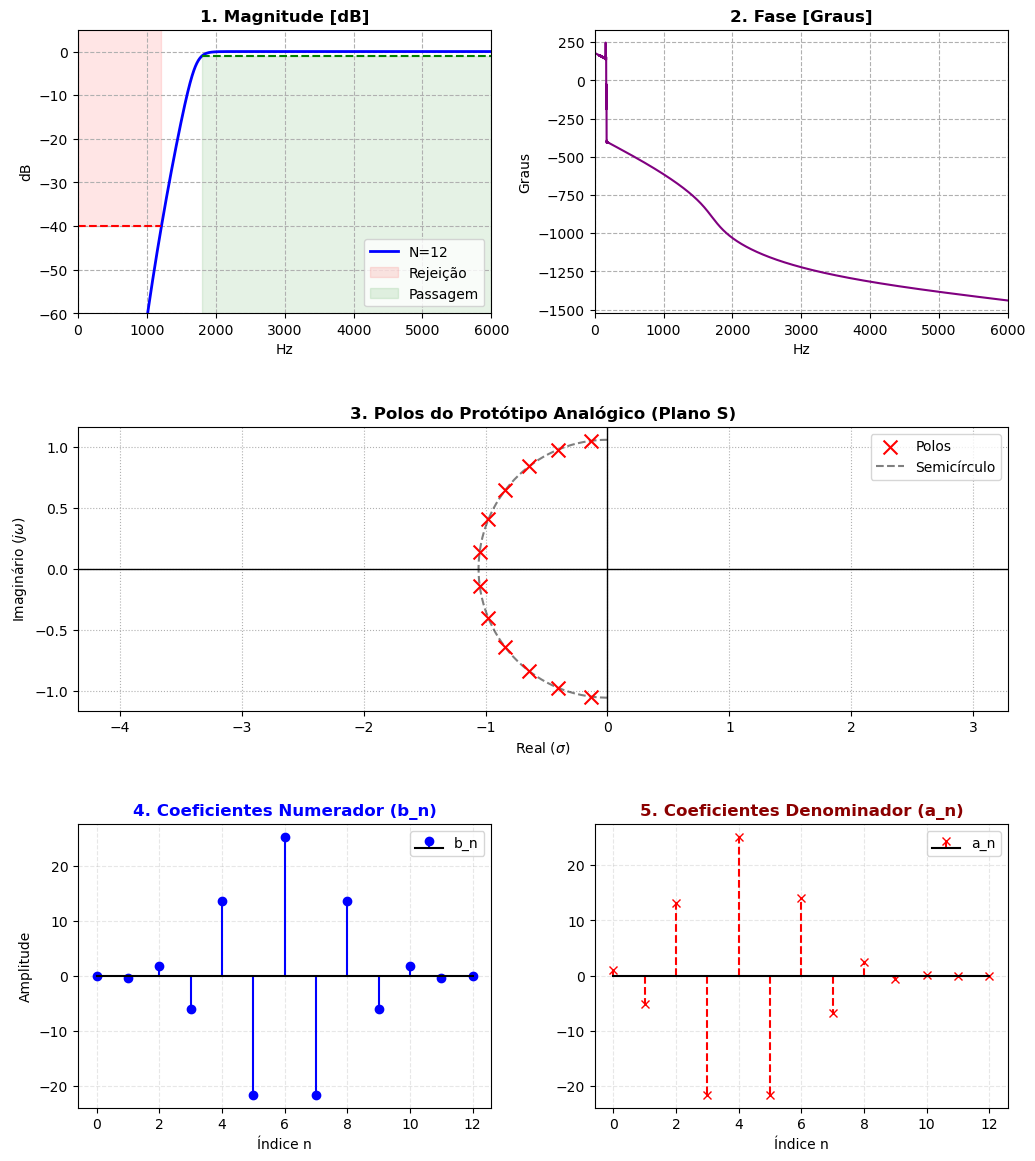

In [64]:

Fs = 12000.0
Fp = 1800.0
Fr = 1200.0
Ap = 1.0
As = 40.0


b, a, N, polos_analogicos, wc = highpass_filter(Fp, Fr, Ap, As, Fs)
    
# Imprime valores no console também
print(f"\n--- Coeficientes Calculados (Ordem {N}) ---")
print("Numerador (b):", np.round(b, 5))
print("Denominador (a):", np.round(a, 5))


# --- Cálculos Preliminares ---
w, h = signal.freqz(b, a, worN=8000)
freqs = (Fs / (2 * np.pi)) * w
# Garante que nenhum valor seja menor que 1e-14 antes de tirar o log
mag_db = 20 * np.log10(np.maximum(np.abs(h), 1e-14))
fase_graus = np.degrees(np.unwrap(np.angle(h)))

# --- Configuração do Layout (3 Linhas, 2 Colunas) ---
fig = plt.figure(figsize=(12, 14))
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.25)

# 1. MAGNITUDE (Topo Esquerda)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(freqs, mag_db, 'b', linewidth=2, label=f'N={N}')
ax1.fill_between([0, Fr], -As, 10, color='red', alpha=0.1, label='Rejeição')
ax1.fill_between([Fp, Fs/2], -Ap, -200, color='green', alpha=0.1, label='Passagem')
ax1.hlines(-As, 0, Fr, colors='r', linestyles='--')
ax1.hlines(-Ap, Fp, Fs/2, colors='g', linestyles='--')
ax1.set_title('1. Magnitude [dB]', fontweight='bold')
ax1.set_ylabel('dB')
ax1.set_xlabel('Hz')
ax1.set_ylim(-As - 20, 5)
ax1.set_xlim(0, Fs/2)
ax1.grid(True, linestyle='--')
ax1.legend(loc='lower right')

# 2. FASE (Topo Direita)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(freqs, fase_graus, 'purple', linewidth=1.5)
ax2.set_title('2. Fase [Graus]', fontweight='bold')
ax2.set_ylabel('Graus')
ax2.set_xlabel('Hz')
ax2.set_xlim(0, Fs/2)
ax2.grid(True, linestyle='--')

# 3. POLOS DO PROTÓTIPO (Meio - Ocupa a linha inteira)
ax3 = fig.add_subplot(gs[1, :])
real_p = np.real(polos_analogicos)
imag_p = np.imag(polos_analogicos)
raio = np.max(np.abs(polos_analogicos)) if polos_analogicos.size > 0 else 1.0

ax3.scatter(real_p, imag_p, color='red', marker='x', s=100, label='Polos', zorder=5)

# Desenha o semicírculo (lado esquerdo do plano-s)
theta_circ = np.linspace(np.pi/2, 3*np.pi/2, 200)
ax3.plot(raio * np.cos(theta_circ), raio * np.sin(theta_circ), 'k--', alpha=0.5, label='Semicírculo')

ax3.set_title('3. Polos do Protótipo Analógico (Plano S)', fontweight='bold')
ax3.set_xlabel('Real ($\\sigma$)')
ax3.set_ylabel('Imaginário ($j\\omega$)')
ax3.axvline(0, color='k', linewidth=1)
ax3.axhline(0, color='k', linewidth=1)
ax3.grid(True, linestyle=':')
ax3.legend()
ax3.set_aspect('equal', adjustable='datalim')

# 4. COEFICIENTES B (Numerador) (Baixo Esquerda)
ax4 = fig.add_subplot(gs[2, 0])
n_b = np.arange(len(b))
ax4.stem(n_b, b, linefmt='b-', markerfmt='bo', basefmt='k-', label='b_n')
ax4.set_title('4. Coeficientes Numerador (b_n)', fontweight='bold', color='blue')
ax4.set_xlabel('Índice n')
ax4.set_ylabel('Amplitude')
ax4.grid(True, linestyle='--', alpha=0.3)
ax4.legend()

# 5. COEFICIENTES A (Denominador) (Baixo Direita)
ax5 = fig.add_subplot(gs[2, 1])
n_a = np.arange(len(a))
ax5.stem(n_a, a, linefmt='r--', markerfmt='rx', basefmt='k-', label='a_n')
ax5.set_title('5. Coeficientes Denominador (a_n)', fontweight='bold', color='darkred')
ax5.set_xlabel('Índice n')
ax5.grid(True, linestyle='--', alpha=0.3)
ax5.legend()

plt.tight_layout()
plt.show()





 Iniciando Projeto de Filtro IIR Butterworth (Passa-Alta)
Ordem calculada: 11
Frequência de corte (-3dB) ajustada: 1877.56 Hz


C:\Users\elmer.farias\AppData\Local\Temp\ipykernel_18116\2394255452.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


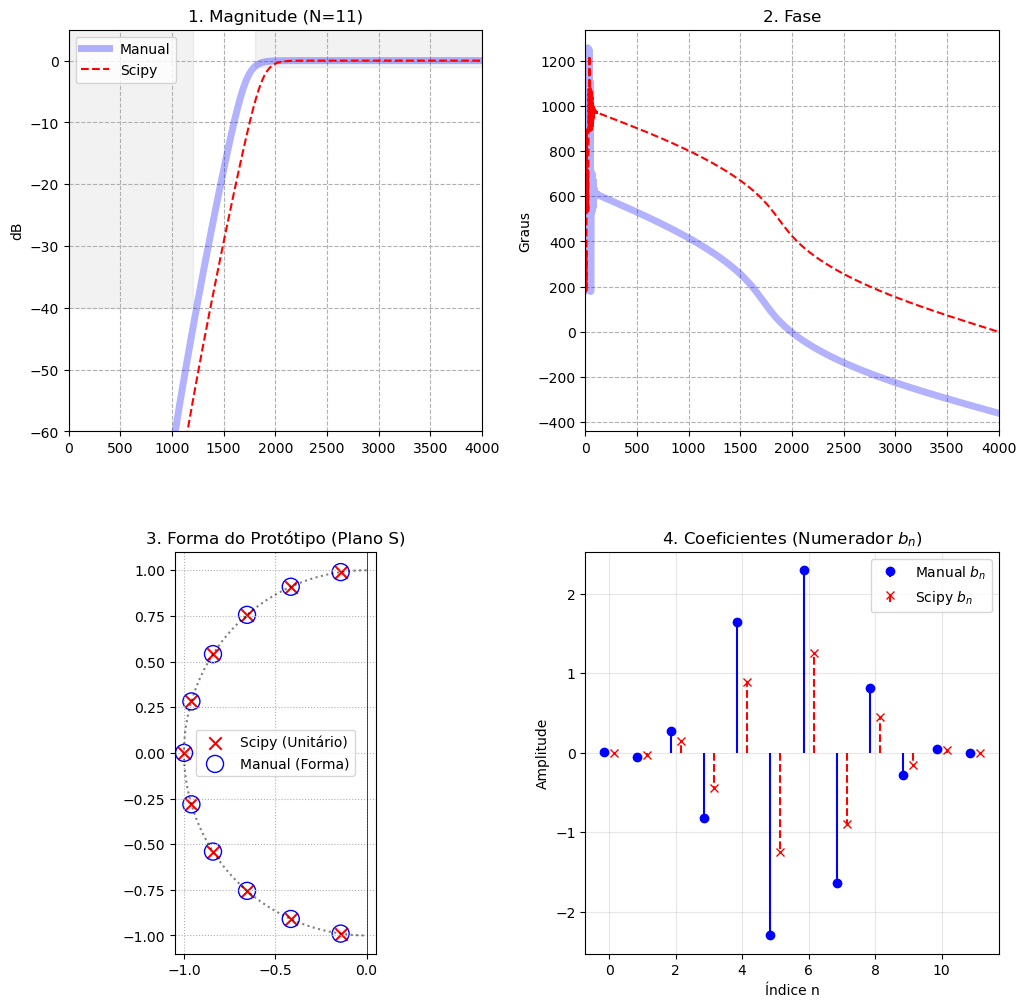

In [66]:
Fs = 8000.0       
Fp = 1800.0       
Fr = 1200.0       
Ap = 1.0          
As = 40.0         


b_man, a_man, N, p_man, Wc_ajustado = highpass_filter(Fp, Fr, Ap, As, Fs)

# 2. Prepara o Scipy para ser IDÊNTICO 
# Convertendo o Wc (rad/s pre-warped) de volta para Hz
fc_hz = (Fs / np.pi) * np.arctan(Wc_ajustado)

print(f"Frequência de corte (-3dB) ajustada: {fc_hz:.2f} Hz")

# 3. Executa o Scipy com a frequência ajustada
b_sci, a_sci = signal.butter(N, fc_hz, btype='high', fs=Fs)

# Protótipo analógico do Scipy (para comparar o semicírculo)
z_proto, p_proto, k_proto = signal.butter(N, 1, btype='low', analog=True, output='zpk')

# --- PLOTAGEM ---
w, h_sci = signal.freqz(b_sci, a_sci, worN=8000)
w, h_man = signal.freqz(b_man, a_man, worN=8000)
freqs = (Fs * 0.5 / np.pi) * w

mag_man = 20 * np.log10(np.maximum(np.abs(h_man), 1e-14))
mag_sci = 20 * np.log10(np.maximum(np.abs(h_sci), 1e-14))
fase_man = np.degrees(np.unwrap(np.angle(h_man)))
fase_sci = np.degrees(np.unwrap(np.angle(h_sci)))

fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

# GRÁFICO 1: MAGNITUDE
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(freqs, mag_man, 'b', linewidth=5, alpha=0.3, label='Manual')
ax1.plot(freqs, mag_sci, 'r--', linewidth=1.5, label='Scipy')
ax1.fill_between([0, Fr], -As, 10, color='gray', alpha=0.1)
ax1.fill_between([Fp, Fs/2], -Ap, 5, color='gray', alpha=0.1)
ax1.set_title(f'1. Magnitude (N={N})')
ax1.set_ylabel('dB')
ax1.set_ylim(-As - 20, 5)
ax1.set_xlim(0, Fs/2)
ax1.grid(True, linestyle='--')
ax1.legend()

# GRÁFICO 2: FASE
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(freqs, fase_man, 'b', linewidth=5, alpha=0.3, label='Manual')
ax2.plot(freqs, fase_sci, 'r--', linewidth=1.5, label='Scipy')
ax2.set_title('2. Fase')
ax2.set_ylabel('Graus')
ax2.set_xlim(0, Fs/2)
ax2.grid(True, linestyle='--')

# GRÁFICO 3: POLOS DO PROTÓTIPO
ax3 = fig.add_subplot(gs[1, 0])
# Scipy (Referência Wn=1)
ax3.scatter(np.real(p_proto), np.imag(p_proto), s=80, marker='x', color='r', label='Scipy (Unitário)')
# (Ajustado por Epsilon)
raio_man = np.mean(np.abs(p_man))
p_man_norm = p_man / raio_man 
ax3.scatter(np.real(p_man_norm), np.imag(p_man_norm), s=150, marker='o', 
            facecolors='none', edgecolors='b', label='Manual (Forma)')

theta = np.linspace(np.pi/2, 3*np.pi/2, 100)
ax3.plot(np.cos(theta), np.sin(theta), 'k:', alpha=0.5)
ax3.set_title('3. Forma do Protótipo (Plano S)')
ax3.axvline(0, color='k', linewidth=0.5)
ax3.set_aspect('equal')
ax3.legend()
ax3.grid(True, linestyle=':')

ax4 = fig.add_subplot(gs[1, 1])
indices = np.arange(len(b_man))
deslocamento = 0.15 # Pequeno shift para ver os dois lado a lado
# Plota coeficientes Manual (Azul, deslocado para esquerda)
ax4.stem(indices - deslocamento, b_man, linefmt='b-', markerfmt='bo', basefmt=' ', label='Manual $b_n$')

# Plota coeficientes Scipy (Vermelho, deslocado para direita)
ax4.stem(indices + deslocamento, b_sci, linefmt='r--', markerfmt='rx', basefmt=' ', label='Scipy $b_n$')

ax4.set_title('4. Coeficientes (Numerador $b_n$)')
ax4.set_ylabel('Amplitude')
ax4.set_xlabel('Índice n')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- PREPARE-SE ---
Vou gravar por 10 segundos usando a taxa de 8000.0Hz.
Gravação de 10 segundos iniciará em...
3...
2...
1... FALE!
--- GRAVAÇÃO CONCLUÍDA ---
Projetando filtro Passa-Alta Manual (Corte ~1600.0Hz)...
 Iniciando Projeto de Filtro IIR Butterworth (Passa-Alta)
Ordem calculada: 15
Aplicando filtro no áudio...
Reproduzindo ORIGINAL...
Reproduzindo FILTRADO (Passa-Alta)...


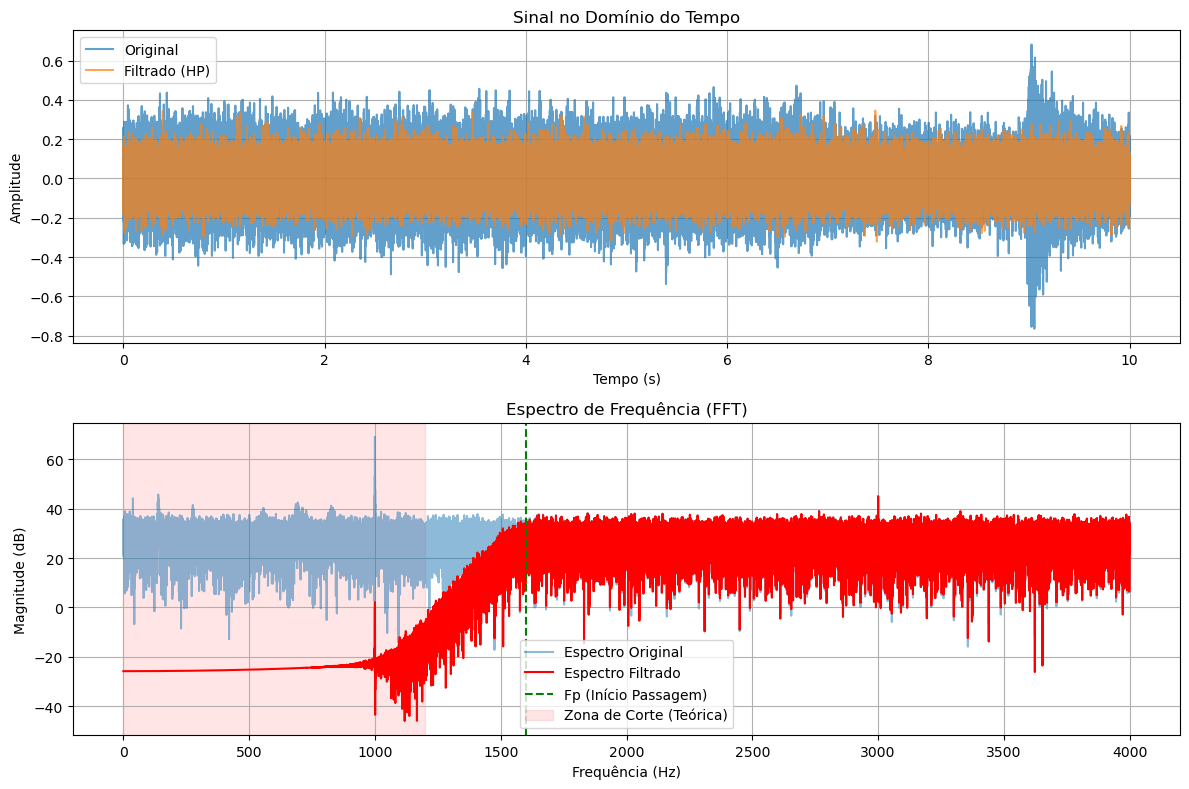

In [ ]:
import sounddevice as sd
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import scipy.signal as sig

Fs = 8000.0       # Taxa de Amostragem 
duracao = 10       # Segundos de gravação
print(f"--- PREPARE-SE ---")
print(f"Vou gravar por {duracao} segundos usando a taxa de {Fs}Hz.")

print("Gravação de 10 segundos iniciará em...")
time.sleep(1); print("3..."); time.sleep(1); print("2..."); time.sleep(1); print("1... FALE!")
# Gravação (Bloqueante - o código espera terminar)

audio_original = sd.rec(int(duracao * Fs), samplerate=int(Fs), channels=1)
sd.wait() # Aguarda a gravação terminar
print("--- GRAVAÇÃO CONCLUÍDA ---")


ruido = np.random.normal(0, 0.1, audio_original.shape)
audio_original += ruido

# Remove a dimensão extra do array (de [N, 1] para [N]) para facilitar
audio_original = audio_original.flatten()


Fp = 1600.0       # Passagem (Só agudos)
Fr = 1200.0       # Rejeição (Corta graves/médios)
Ap = 1.0
As = 40.0

print(f"Projetando filtro Passa-Alta Manual (Corte ~{Fp}Hz)...")

# Chamando SUA função (Certifique-se de que ela está definida no código)
b, a, N, p_man, Wc = highpass_filter(Fp, Fr, Ap, As, Fs)


print("Aplicando filtro no áudio...")

# A função lfilter implementa a equação a diferenças usando b e a
audio_filtrado = signal.lfilter(b, a, audio_original)

# Play
print("Reproduzindo ORIGINAL...")
sd.play(audio_original, Fs)
sd.wait()

print("Reproduzindo FILTRADO (Passa-Alta)...")
sd.play(audio_filtrado, Fs)
sd.wait()


# plotar o Espectro de Frequência para provar que os graves foram cortados
# Função auxiliar para calcular FFT
def calcular_fft(sinal, fs):
    n = len(sinal)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    mag = np.abs(np.fft.rfft(sinal))
    return freqs, 20 * np.log10(mag + 1e-12)

f_orig, spec_orig = calcular_fft(audio_original, Fs)
f_filt, spec_filt = calcular_fft(audio_filtrado, Fs)

plt.figure(figsize=(12, 8))

# Plot 1: Sinal no Tempo
plt.subplot(2, 1, 1)
t = np.arange(len(audio_original)) / Fs
plt.plot(t, audio_original, label='Original', alpha=0.7)
plt.plot(t, audio_filtrado, label='Filtrado (HP)', alpha=0.7)
plt.title('Sinal no Domínio do Tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# Plot 2: Espectro de Frequência (A prova real)
plt.subplot(2, 1, 2)
plt.plot(f_orig, spec_orig, label='Espectro Original', alpha=0.5)
plt.plot(f_filt, spec_filt, 'r', label='Espectro Filtrado')

# Desenhando a área que o filtro deveria cortar
plt.axvline(Fp, color='g', linestyle='--', label='Fp (Início Passagem)')
plt.axvspan(0, Fr, color='red', alpha=0.1, label='Zona de Corte (Teórica)')

plt.title('Espectro de Frequência (FFT)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [71]:
print("Reproduzindo ORIGINAL...")
sd.play(audio_original, Fs)
sd.wait()

print("Reproduzindo FILTRADO (Passa-Alta)...")
sd.play(audio_filtrado, Fs)
sd.wait()


Reproduzindo ORIGINAL...
Reproduzindo FILTRADO (Passa-Alta)...
